In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("sales_data - Sheet1.csv")

df.head()

,Order_ID,Date,Region,Sales_Channel,Customer_Segment,Product,Units_Sold,Unit_Price,Discount,Revenue,Country
0,1001,2026-01-03,North,Online,Consumer,Laptop,2,900.0,0.10,1620,France
1,1002,2026-01-04,South,Retail,Corporate,Phone,4,600.0,0.05,2280,France
2,1003,2026-01-05,north,online,Consumer,Tablet,3,350.0,NaN,1050,France
3,1004,2026-01-05,West,ONLINE,Small Business,Monitor,1,0.2,0.00,1100,France
4,1005,2026-01-07,East,Retail,NaN,Laptop,6,950.0,0.10,855,France


In [3]:
print("Shape of dataset:")
print(df.shape)

Shape of dataset:
(99, 11)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          99 non-null     int64  
 1   Date              99 non-null     object 
 2   Region            99 non-null     object 
 3   Sales_Channel     90 non-null     object 
 4   Customer_Segment  95 non-null     object 
 5   Product           99 non-null     object 
 6   Units_Sold        99 non-null     int64  
 7   Unit_Price        99 non-null     float64
 8   Discount          89 non-null     float64
 9   Revenue           99 non-null     int64  
 10  Country           99 non-null     object 
dtypes: float64(2), int64(3), object(6)
memory usage: 8.6+ KB


In [5]:
df.isnull().sum()

,0
Order_ID,0
Date,0
Region,0
Sales_Channel,9
Customer_Segment,4
Product,0
Units_Sold,0
Unit_Price,0
Discount,10
Revenue,0


In [6]:
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 0


In [7]:
categorical = [
    "Region",
    "Sales_Channel",
    "Customer_Segment",
    "Product",
    "Country"
]

for col in categorical:
    df[col] = df[col].str.lower().str.strip()
    # to make everystring lowr caps

In [10]:
df["Sales_Channel"] = df["Sales_Channel"].fillna(df["Sales_Channel"].mode()[0])

df["Customer_Segment"] = df["Customer_Segment"].fillna(
    df["Customer_Segment"].mode()[0]
)

df["Discount"] = df["Discount"].fillna(
    df["Discount"].median()
)
#hadnling missing values

In [11]:
df = df.drop_duplicates()

print(df.shape)

(99, 11)


In [12]:
print(df["Country"].value_counts())

Country
france    99
Name: count, dtype: int64


In [13]:
df = df.drop(columns="Country")

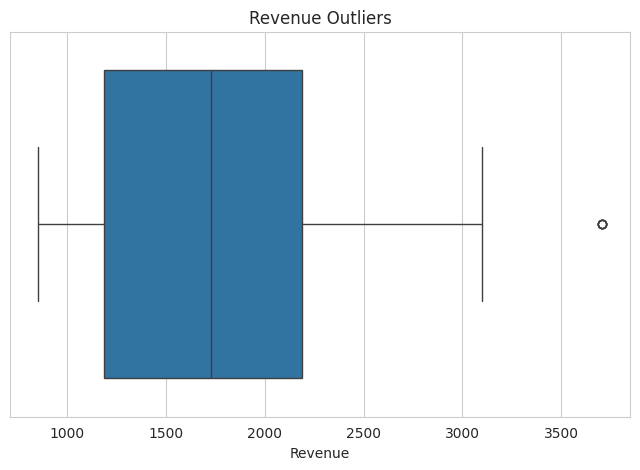

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Revenue"])
plt.title("Revenue Outliers")
plt.show()

#to detect outliers

In [15]:
df.describe()
# summary

,Order_ID,Units_Sold,Unit_Price,Discount,Revenue
count,99.000000,99.000000,99.000000,99.000000,99.000000
mean,1050.464646,4.444444,1746.264646,0.062121,1791.777778
std,28.914481,2.218761,12009.450708,0.041705,711.095527
min,1001.000000,1.000000,0.200000,0.000000,855.000000
25%,1025.500000,2.000000,300.000000,0.050000,1190.000000
50%,1051.000000,4.000000,600.000000,0.050000,1729.000000
75%,1075.500000,6.000000,800.000000,0.100000,2190.000000
max,1099.000000,8.000000,120000.000000,0.150000,3705.000000


In [16]:
Q1 = df["Revenue"].quantile(0.25)
Q3 = df["Revenue"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Revenue"] < lower) |
    (df["Revenue"] > upper)
]

outliers
# to calculate iqr

,Order_ID,Date,Region,Sales_Channel,Customer_Segment,Product,Units_Sold,Unit_Price,Discount,Revenue
5,1006,2026-01-08,north,online,consumer,phone,4,650.0,0.05,3705
25,1026,2026-01-08,north,online,consumer,phone,6,650.0,0.05,3705
45,1046,2026-01-16,north,online,consumer,phone,6,650.0,0.05,3705
65,1066,2026-01-19,north,retail,consumer,phone,6,220.0,0.05,3705
85,1086,2026-01-08,north,online,consumer,phone,6,600.0,0.05,3705


In [17]:
print("Missing Discount by Region")

print(
    df.groupby("Region")["Discount"]
    .apply(lambda x: x.isnull().sum())
)

print()

print("Missing Discount by Product")

print(
    df.groupby("Product")["Discount"]
    .apply(lambda x: x.isnull().sum())
)

Missing Discount by Region
Region
east     0
north    0
south    0
west     0
Name: Discount, dtype: int64

Missing Discount by Product
Product
laptop     0
monitor    0
phone      0
tablet     0
Name: Discount, dtype: int64


In [18]:
product_revenue = (
    df.groupby("Product")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(product_revenue)

Product
phone      65247
tablet     40352
laptop     37885
monitor    33902
Name: Revenue, dtype: int64


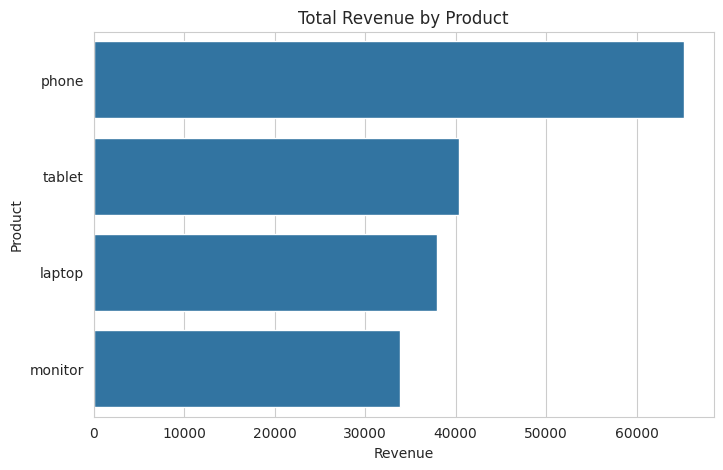

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=product_revenue.values,
    y=product_revenue.index
)

plt.title("Total Revenue by Product")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

In [20]:
segment = (
    df.groupby("Customer_Segment")
      .agg({"Units_Sold":"sum"})
      .sort_values("Units_Sold", ascending=False)
)

segment

,Units_Sold
Customer_Segment,
consumer,267
corporate,135
small business,38


In [21]:
channel = (
    df.groupby("Sales_Channel")
      .agg({"Revenue":"sum"})
      .sort_values("Revenue", ascending=False)
)

channel

,Revenue
Sales_Channel,
online,105111
retail,72275


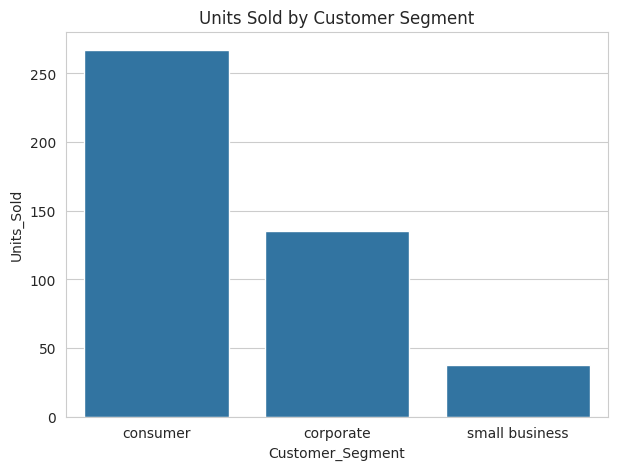

In [22]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=segment.index,
    y=segment["Units_Sold"]
)

plt.title("Units Sold by Customer Segment")

plt.show()

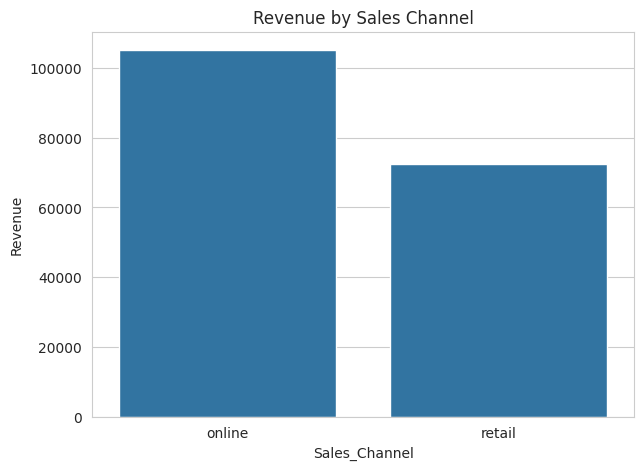

In [23]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=channel.index,
    y=channel["Revenue"]
)

plt.title("Revenue by Sales Channel")

plt.show()

In [24]:
region = (
    df.groupby("Region")["Revenue"]
      .sum()
      .sort_values()
)

region

,Revenue
Region,
east,28410
west,34392
south,47297
north,67287


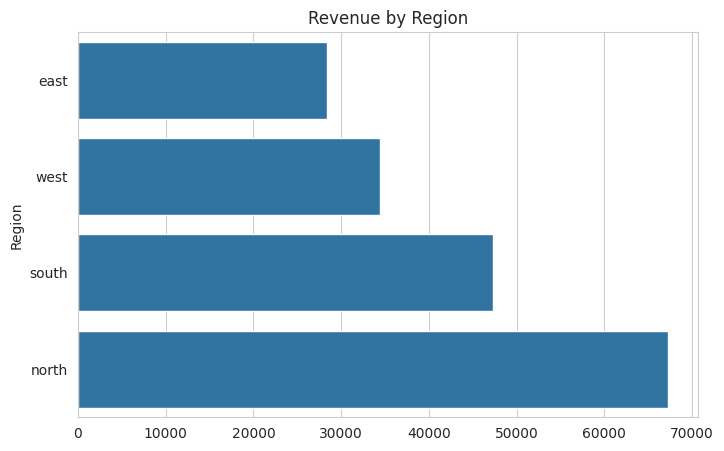

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region.values,
    y=region.index
)

plt.title("Revenue by Region")

plt.show()

In [26]:
df[["Discount","Revenue"]].corr()

#to show corrolation

,Discount,Revenue
Discount,1.000000,-0.091897
Revenue,-0.091897,1.000000


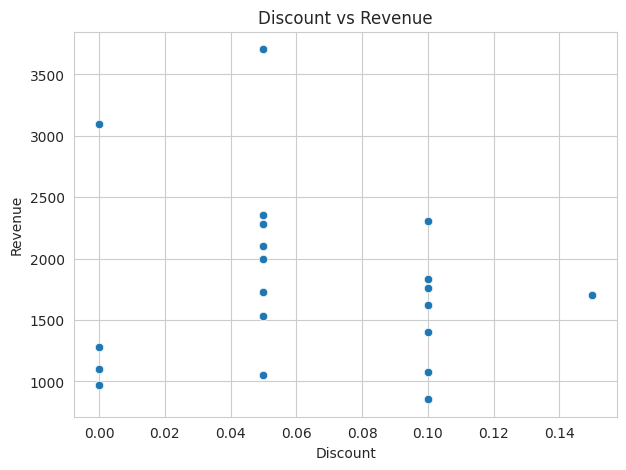

In [27]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Revenue"
)

plt.title("Discount vs Revenue")

plt.show()

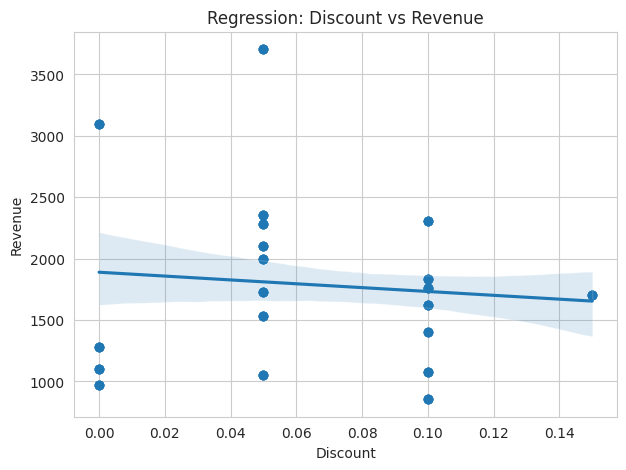

In [28]:
plt.figure(figsize=(7,5))

sns.regplot(
    data=df,
    x="Discount",
    y="Revenue"
)

plt.title("Regression: Discount vs Revenue")

plt.show()

In [29]:
popular = (
    df.groupby("Product")["Units_Sold"]
      .sum()
      .sort_values(ascending=False)
)

popular

,Units_Sold
Product,
monitor,134
tablet,121
phone,117
laptop,68


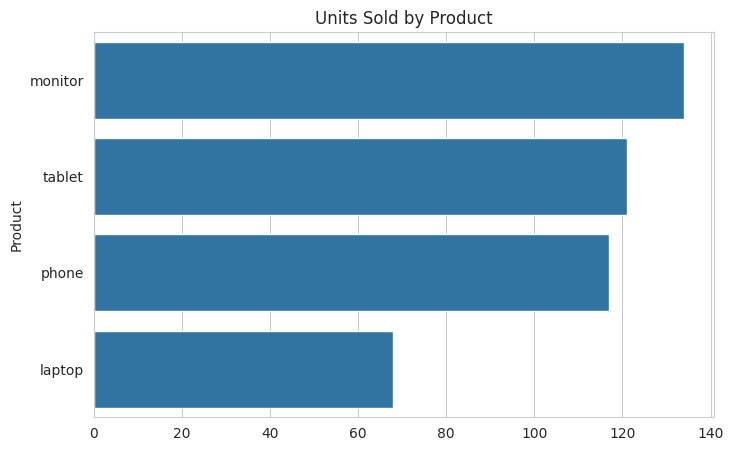

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=popular.values,
    y=popular.index
)

plt.title("Units Sold by Product")

plt.show()

In [31]:
profit = (
    df.groupby("Product")
      .agg(
          Units=("Units_Sold","sum"),
          Revenue=("Revenue","sum")
      )
      .sort_values("Revenue", ascending=False)
)

profit

,Units,Revenue
Product,,
phone,117,65247
tablet,121,40352
laptop,68,37885
monitor,134,33902


In [32]:
df["Date"] = pd.to_datetime(df["Date"])

In [33]:
monthly = (
    df.groupby(df["Date"].dt.month)["Revenue"]
      .sum()
)

monthly

,Revenue
Date,
1,177386


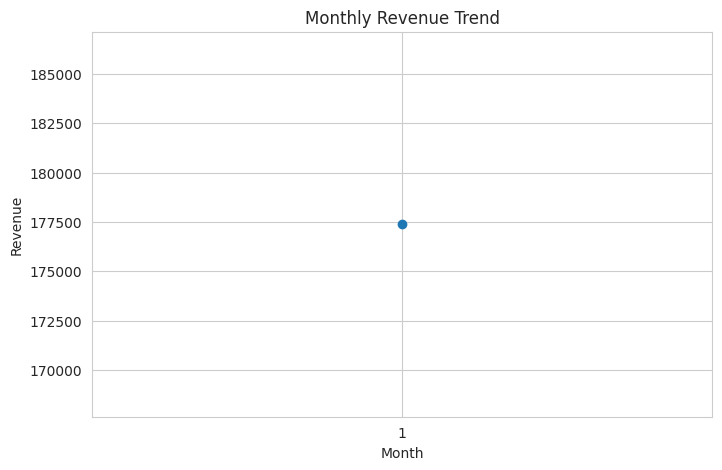

In [34]:
plt.figure(figsize=(8,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o"
)

plt.xticks(monthly.index)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [35]:
df["Revenue"].describe()

,Revenue
count,99.000000
mean,1791.777778
std,711.095527
min,855.000000
25%,1190.000000
50%,1729.000000
75%,2190.000000
max,3705.000000


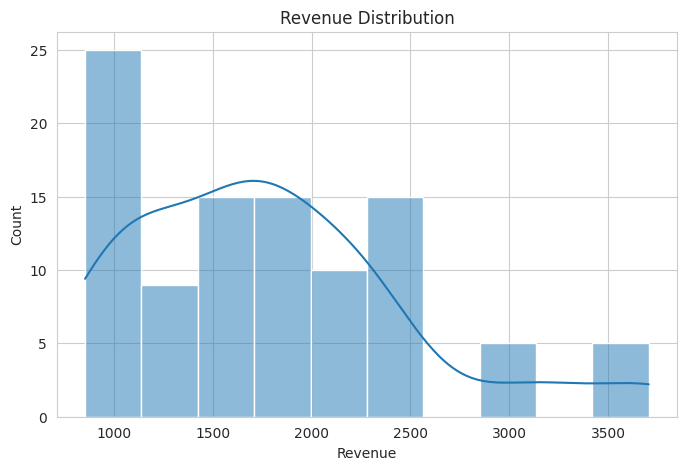

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Revenue"],
    kde=True,
    bins=10
)

plt.title("Revenue Distribution")

plt.show()